# Project Description

This project develops a machine learning classification pipeline to predict student grades using a dataset of 10,000 student records. The dataset contains information such as study hours, attendance percentage, previous GPA, sleep hours, participation in extracurricular activities, and tutoring sessions.

The project begins with data preprocessing, including handling missing values, encoding categorical features, and standardizing numerical data. A K-Nearest Neighbors (KNN) classifier is then implemented from scratch using NumPy and evaluated on the dataset. Additionally, Logistic Regression, Decision Tree, and Random Forest models are trained using Scikit-learn.

The performance of all models is compared using accuracy scores, confusion matrices, classification reports, and cross-validation to determine the most effective model for predicting student grades.


# Dataset Description

The dataset contains 10,000 student records and is designed for a multi-class classification problem. The target variable is **grade**, which represents the student's final academic performance category. The dataset includes the following features:

* **study_hours:** Number of hours spent studying.
* **attendance_pct:** Student attendance percentage.
* **previous_gpa:** Previous academic GPA.
* **sleep_hours:** Average daily sleep hours.
* **extracurricular:** Participation in extracurricular activities (Yes/No).
* **tutoring_sessions:** Number of tutoring sessions attended.

These features are used to predict the student's grade and analyze the factors that influence academic performance.



Introduction
Project Description
Dataset Description
Data Preprocessing
Model Implementation
KNN from Scratch
Logistic Regression
Decision Tree
Random Forest
Results and Evaluation
Conclusion

###Import libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score


### Load dataset

In [4]:

df = pd.read_csv('/content/students_performance.csv')


### Shape

In [5]:
df_shape = df.shape
print("Shape of the dataset:", df_shape)

Shape of the dataset: (10000, 8)


### Missing values count

In [6]:
missing_counts = df.isnull().sum()
print("Missing values count:\n", missing_counts)

Missing values count:
 student_id             0
study_hours            0
attendance_pct         0
previous_gpa         320
sleep_hours          300
extracurricular        0
tutoring_sessions      0
grade                  0
dtype: int64


# Target distribution

Class distribution:
 grade
B    35.56
C    34.93
F    15.02
A    14.49
Name: proportion, dtype: float64


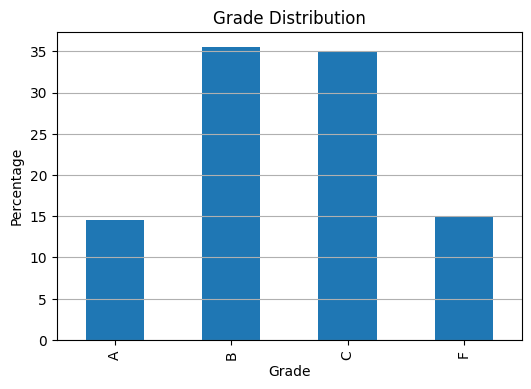

In [29]:
class_distribution = df['grade'].value_counts(normalize=True) * 100
print("Class distribution:\n", class_distribution)
plt.figure(figsize=(6,4))
class_distribution.sort_index().plot(kind='bar')
plt.title("Grade Distribution")
plt.xlabel("Grade")
plt.ylabel("Percentage")
plt.grid(axis='y')
plt.show()

## Data Cleaning

### Create copy

In [8]:

df_clean = df.copy()

### Fill missing values with median

In [9]:
df_clean['previous_gpa'] = df_clean['previous_gpa'].fillna(
    df_clean['previous_gpa'].median())

df_clean['sleep_hours'] = df_clean['sleep_hours'].fillna(
    df_clean['sleep_hours'].median())


### Label encoding

In [10]:
label_map = {'Yes': 1, 'No': 0}

df_clean['extracurricular'] = df_clean['extracurricular'].map(label_map)
print(df_clean['extracurricular'].head())

0    0
1    0
2    0
3    0
4    0
Name: extracurricular, dtype: int64


### Drop student_id

In [11]:
df_clean = df_clean.drop(columns=['student_id'])

### Features and target

In [12]:
X = df_clean.drop(columns=['grade'])
y = df_clean['grade']

In [30]:
print("\nFirst 5 rows after cleaning:")
print(df_clean.head())

print("\nRemaining Missing Values:")
print(df_clean.isnull().sum())


First 5 rows after cleaning:
   study_hours  attendance_pct  previous_gpa  sleep_hours  extracurricular  \
0         8.61            91.9          3.69         7.14                0   
1         5.08            53.0          2.50         4.51                0   
2        15.00            92.8          3.34         7.55                0   
3         2.40            54.6          1.46         7.11                0   
4         4.13            77.9          1.97         7.68                0   

   tutoring_sessions grade  
0                  6     A  
1                  4     C  
2                  7     A  
3                  2     F  
4                  2     C  

Remaining Missing Values:
study_hours          0
attendance_pct       0
previous_gpa         0
sleep_hours          0
extracurricular      0
tutoring_sessions    0
grade                0
dtype: int64


## Manual Standard Scaling

### Mean and std

In [13]:
scaler_mean = X.mean()
scaler_std = X.std()
print("Mean:\n", scaler_mean)
print("Standard deviation:\n", scaler_std)

Mean:
 study_hours           6.973721
attendance_pct       75.268230
previous_gpa          2.764480
sleep_hours           6.691763
extracurricular       0.512600
tutoring_sessions     3.548300
dtype: float64
Standard deviation:
 study_hours           3.141908
attendance_pct       14.215914
previous_gpa          0.683436
sleep_hours           1.381401
extracurricular       0.499866
tutoring_sessions     1.776396
dtype: float64


### Standard scaling

In [14]:
X_scaled = (X - scaler_mean) / scaler_std
print("Scaled features:\n", X_scaled.head())

Scaled features:
    study_hours  attendance_pct  previous_gpa  sleep_hours  extracurricular  \
0     0.520792        1.169940      1.354216     0.324480        -1.025474   
1    -0.602730       -1.566430     -0.386986    -1.579384        -1.025474   
2     2.554588        1.233250      0.842098     0.621280        -1.025474   
3    -1.455715       -1.453880     -1.908708     0.302763        -1.025474   
4    -0.905094        0.185128     -1.162479     0.715387        -1.025474   

   tutoring_sessions  
0           1.380154  
1           0.254279  
2           1.943092  
3          -0.871596  
4          -0.871596  


### Train-test split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

## KNN From Scratch

In [16]:
def knn_predict(X_train_data, y_train_data, X_test_data, k=5):

    predictions = []

    label_order = ['A', 'B', 'C', 'F']

    for test_point in X_test_data:

        distances = np.sqrt(
            np.sum((X_train_data - test_point) ** 2, axis=1)
        )

        nearest_indices = np.argsort(distances)[:k]

        nearest_labels = y_train_data[nearest_indices]

        counts = {}

        for label in nearest_labels:
            counts[label] = counts.get(label, 0) + 1

        max_vote = max(counts.values())

        candidates = [
            label for label, count in counts.items()
            if count == max_vote
        ]

        pred = sorted(candidates, key=lambda x: label_order.index(x))[0]

        predictions.append(pred)

    return np.array(predictions)

###Convert to NumPy

In [17]:
X_train_np = np.array(X_train)
y_train_np = np.array(y_train)

X_test_np = np.array(X_test)
y_test_np = np.array(y_test)

##K = 5

In [18]:
knn_preds_k5 = knn_predict(
    X_train_np,
    y_train_np,
    X_test_np,
    k=5
)

knn_accuracy_k5 = np.mean(knn_preds_k5 == y_test_np)

##K = 3

In [19]:
knn_preds_k3 = knn_predict(
    X_train_np,
    y_train_np,
    X_test_np,
    k=3
)

knn_accuracy_k3 = np.mean(knn_preds_k3 == y_test_np)

In [31]:
print("KNN Accuracy (k=5):", knn_accuracy_k5)
print("KNN Accuracy (k=3):", knn_accuracy_k3)

KNN Accuracy (k=5): 0.834
KNN Accuracy (k=3): 0.821


## Scikit-Learn Models

###Logistic Regression

In [34]:
logreg_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logreg_model.fit(X_train, y_train)

logreg_preds = logreg_model.predict(X_test)

logreg_accuracy = accuracy_score(
    y_test,
    logreg_preds
)


###Decision Tree

In [35]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)

dt_accuracy = accuracy_score(
    y_test,
    dt_preds
)


###Random Forest

In [33]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_preds
)


In [36]:
print("Logistic Regression Accuracy:", logreg_accuracy)
print("Decision Tree Accuracy:", dt_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Logistic Regression Accuracy: 0.856
Decision Tree Accuracy: 0.778
Random Forest Accuracy: 0.8535


## Evaluation

In [23]:
accuracies = {
    'KNN': knn_accuracy_k5,
    'LogisticRegression': logreg_accuracy,
    'DecisionTree': dt_accuracy,
    'RandomForest': rf_accuracy
}

best_model_name = max(
    accuracies,
    key=accuracies.get
)

In [24]:
if best_model_name == 'KNN':
    best_preds = knn_preds_k5

elif best_model_name == 'LogisticRegression':
    best_preds = logreg_preds

elif best_model_name == 'DecisionTree':
    best_preds = dt_preds

else:
    best_preds = rf_preds



In [25]:
confusion_mat = confusion_matrix(
    y_test,
    best_preds
)

class_report = classification_report(
    y_test,
    best_preds,
    output_dict=True
)

In [37]:
print("Best Model:", best_model_name)

print("\nConfusion Matrix:")
print(confusion_mat)

print("\nClassification Report:")
print(pd.DataFrame(class_report).transpose())

Best Model: LogisticRegression

Confusion Matrix:
[[248  50   0   0]
 [ 36 635  59   0]
 [  0  41 588  46]
 [  0   0  56 241]]

Classification Report:
              precision    recall  f1-score   support
A              0.873239  0.832215  0.852234   298.000
B              0.874656  0.869863  0.872253   730.000
C              0.836415  0.871111  0.853411   675.000
F              0.839721  0.811448  0.825342   297.000
accuracy       0.856000  0.856000  0.856000     0.856
macro avg      0.856008  0.846159  0.850810  2000.000
weighted avg   0.856351  0.856000  0.855945  2000.000


##Task 7: Comparison & Cross Validation

In [27]:
comparison_df = pd.DataFrame({
    'Model': [
        'KNN-k5',
        'LogisticRegression',
        'DecisionTree',
        'RandomForest'
    ],
    'Accuracy': [
        knn_accuracy_k5,
        logreg_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

In [38]:
print("\nModel Comparison:")
print(comparison_df)


Model Comparison:
                Model  Accuracy
0              KNN-k5    0.8340
1  LogisticRegression    0.8560
2        DecisionTree    0.7780
3        RandomForest    0.8535


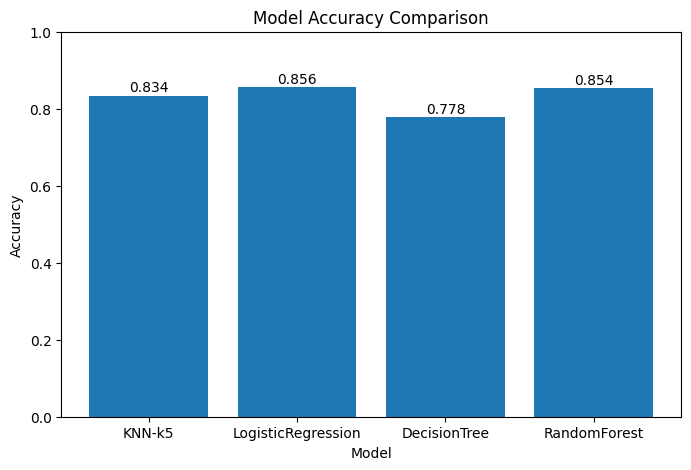

In [39]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df['Model'],
    comparison_df['Accuracy']
)

plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

for i, v in enumerate(comparison_df['Accuracy']):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.show()

In [28]:
cv_scores = cross_val_score(
    rf_model,
    X_scaled,
    y,
    cv=5
)

In [40]:
print("\nCross Validation Scores:")
print(cv_scores)

print("Mean CV Accuracy:", cv_scores.mean())


Cross Validation Scores:
[0.86  0.85  0.855 0.847 0.849]
Mean CV Accuracy: 0.8522000000000001


# Conclusion

This project successfully developed a machine learning pipeline for student grade prediction. Data preprocessing techniques were applied to prepare the dataset, and a K-Nearest Neighbors classifier was implemented from scratch using NumPy. The performance of KNN was compared with Logistic Regression, Decision Tree, and Random Forest models. Evaluation metrics and cross-validation results were used to identify the most effective model for the given dataset and demonstrate the application of machine learning techniques in educational performance prediction.
